# 🛡️ Advanced Fraud Detection Pipeline
## Machine Learning & Behavior Feature Engineering for Anti-Fraud & Risk Analytics
**Prepared by: Alina T. | Anti-Fraud & Risk Data Scientist**

---

### 📌 Project Context & Overview
This project implements a production-grade exploratory data analysis (EDA) and advanced feature engineering pipeline using the **IEEE-CIS Fraud Detection dataset (Vesta Corp)**. The ultimate goal is to benchmark transaction risks and engineer robust behavioral flags to improve predictive model performance in high-imbalance environments (~3.5% fraud rate).

### 🛠️ Strategic Pipeline Architecture:
1. **Exploratory Data Analysis (EDA):** Assessing transaction volumes, temporal patterns (`TransactionDT`), and financial behaviors (`TransactionAmt`).
2. **Identity & Device Analysis:** Left-joining multi-source tables to extract cross-device risk signals (Browsers, Device types, Verification proxy statuses).
3. **Advanced Feature Engineering:** Group-by card aggregations (`.transform()`), behavioral profile creation, and velocity/anomaly checks (`Amt_to_Mean_Card`).

# STEP 1: Environment Setup & Optimized Data Loading

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os
import warnings

# Muting runtime and formatting warnings for clean GitHub presentation
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Setting visual aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

def reduce_mem_usage(df):
    """ Iterate through all columns of a dataframe and modify the data type
        to drastically reduce memory footprint. Handles NaN values safely.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            # Check if column is datetime-like or completely empty to avoid errors
            if df[col].isnull().all():
                continue
                
            c_min = df[col].min()
            c_max = df[col].max()
            
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)  
            else:
                # Safely downcasting floats while ignoring NaN constraints warnings
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')
            
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memory usage decreased to {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

print("Loading raw transactional records...")
train_transaction = pd.read_csv('train_transaction.csv')
train_transaction = reduce_mem_usage(train_transaction)

Loading raw transactional records...
Memory usage decreased to 487.16 MB (72.6% reduction)


# STEP 2: Financial Volume & Temporal Analysis

=== Transaction Amount Analysis (TransactionAmt) ===
               mean  median
isFraud                    
0        134.511856    68.5
1        149.244354    75.0

Difference between average Fraud vs Legitimate transaction: 14.73

=== Temporal Risk Extraction (TransactionDT) ===
           Total_Transactions  Fraud_Rate_%
HourOfDay                                  
0                       37795          3.14
1                       32797          3.13
2                       26732          3.75
3                       20802          3.83
4                       14839          5.19
5                        9701          7.03
6                        6007          7.77
7                        3704         10.61
8                        2591          9.30
9                        2479          9.00
10                       3627          5.32
11                       6827          3.88
12                      12451          3.04
13                      20315          2.29
14            

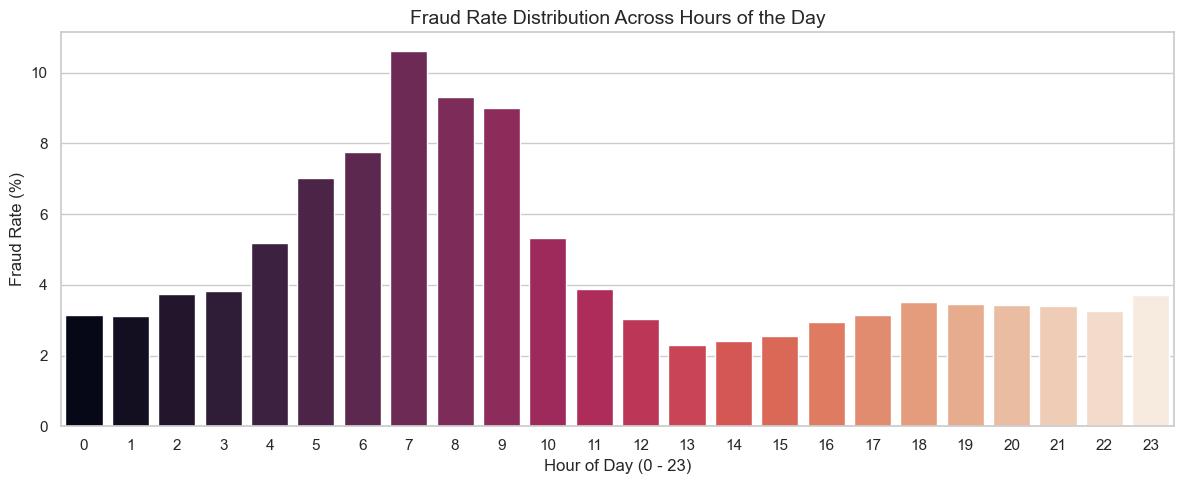

In [11]:
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings('ignore', category=PerformanceWarning)

print("=== Transaction Amount Analysis (TransactionAmt) ===")
# Grouping by target variable to compare statistical distributions
amounts_analysis = train_transaction.groupby('isFraud')['TransactionAmt'].agg(['mean', 'median'])
print(amounts_analysis)

avg_fraud = amounts_analysis.loc[1, 'mean']
avg_legal = amounts_analysis.loc[0, 'mean']
print(f"\nDifference between average Fraud vs Legitimate transaction: {abs(avg_fraud - avg_legal):.2f}\n")


print("=== Temporal Risk Extraction (TransactionDT) ===")
# Feature Engineering: Extracting cyclical 'HourOfDay' feature
train_transaction['HourOfDay'] = (train_transaction['TransactionDT'] // 3600) % 24

# De-fragmenting the dataframe structure after adding a new column
train_transaction = train_transaction.copy()

# Calculating transaction velocity and raw fraud probability per hour
tx_per_hour = train_transaction['HourOfDay'].value_counts().sort_index()
fraud_rate_per_hour = (train_transaction.groupby('HourOfDay')['isFraud'].mean() * 100).round(2)

time_analysis = pd.DataFrame({
    'Total_Transactions': tx_per_hour,
    'Fraud_Rate_%': fraud_rate_per_hour
})
print(time_analysis)

# Data Visualization: Using 'rocket' palette for professional risk analytics style
plt.figure(figsize=(12, 5))
sns.barplot(
    x=time_analysis.index, 
    y=time_analysis['Fraud_Rate_%'], 
    hue=time_analysis.index, 
    palette='rocket', 
    legend=False
)
plt.title('Fraud Rate Distribution Across Hours of the Day', fontsize=14)
plt.xlabel('Hour of Day (0 - 23)', fontsize=12)
plt.ylabel('Fraud Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()

# STEP 3: Multi-Source Data Merging & Identity Risk Profiling

In [12]:
print("Loading identity records...")
train_identity = pd.read_csv('train_identity.csv')
train_identity = reduce_mem_usage(train_identity)

print(f"\nTransactions rows count: {len(train_transaction)}")
print(f"Identity rows count: {len(train_identity)}")

# Performing LEFT JOIN to keep all transaction records intact
df_merged = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
print(f"Merged Dataset Shape: {df_merged.shape}\n")

# Memory cleanup of redundant dataframes
del train_transaction, train_identity
gc.collect()

print("=== Fraud Rate by Device Type ===")
device_analysis = df_merged.groupby('DeviceType')['isFraud'].agg(['count', 'mean'])
device_analysis['Fraud_Rate_%'] = (device_analysis['mean'] * 100).round(2)
print(device_analysis[['count', 'Fraud_Rate_%']])


print("\n=== Top 3 High-Risk Browsers (id_31) ===")
# Filtering rare browsers (< 1000 tx) to avoid statistical noise and prevent overfitting
browser_filter = df_merged.groupby('id_31')['isFraud'].count()
popular_browsers = browser_filter[browser_filter > 1000].index

browser_analysis = df_merged[df_merged['id_31'].isin(popular_browsers)].groupby('id_31')['isFraud'].mean() * 100
print(browser_analysis.sort_values(ascending=False).head(3).round(2))


print("\n=== Verification Proxy Status Analysis (id_15) ===")
if 'id_15' in df_merged.columns:
    proxy_analysis = df_merged.groupby('id_15')['isFraud'].agg(['count', 'mean'])
    proxy_analysis['Fraud_Rate_%'] = (proxy_analysis['mean'] * 100).round(2)
    print(proxy_analysis[['count', 'Fraud_Rate_%']])
else:
    print("Column id_15 not found in the merged dataframe.")

Loading identity records...
Memory usage decreased to 10.00 MB (77.8% reduction)

Transactions rows count: 590540
Identity rows count: 144233
Merged Dataset Shape: (590540, 435)

=== Fraud Rate by Device Type ===
            count  Fraud_Rate_%
DeviceType                     
desktop     85165          6.52
mobile      55645         10.17

=== Top 3 High-Risk Browsers (id_31) ===
id_31
chrome generic             16.81
chrome 64.0 for android    15.89
chrome 65.0 for android    14.72
Name: isFraud, dtype: float64

=== Verification Proxy Status Analysis (id_15) ===
         count  Fraud_Rate_%
id_15                       
Found    67728         10.51
New      61612          4.92
Unknown  11645          9.19


# STEP 4: Advanced Behavioral Feature Engineering & Card Aggregations

In [21]:
print("Generating unique Card Identifiers...")
card_cols = ['card1', 'card2', 'card3', 'card5']
df_merged[card_cols] = df_merged[card_cols].fillna(0).astype(int).astype(str)

# Combining card features into a composite behavioral signature
df_merged['Card_ID'] = (
    df_merged['card1'] + '_' + 
    df_merged['card2'] + '_' + 
    df_merged['card3'] + '_' + 
    df_merged['card5']
)
print(f"Total Unique Card Profiles Identified: {df_merged['Card_ID'].nunique()}")


print("\nComputing historical card-level aggregations via .transform()...")
# Engineering historical baselines per card profile
df_merged['Card_Tx_Count'] = df_merged.groupby('Card_ID')['TransactionID'].transform('count')
df_merged['Card_Mean_Amt'] = df_merged.groupby('Card_ID')['TransactionAmt'].transform('mean')

# Normalization: Current transaction cost ratio to the card's average historical check
df_merged['Amt_to_Mean_Card'] = df_merged['TransactionAmt'] / df_merged['Card_Mean_Amt']

print("\nSample Engineered Behavioral Features:")
print(df_merged[['Card_ID', 'TransactionAmt', 'Card_Tx_Count', 'Card_Mean_Amt', 'Amt_to_Mean_Card']].head())


print("\n=== Risk Feature Validation & Anomaly Detection ===")
# Isolating transaction anomalies (Current purchase amount exceeds historical card mean by > 5 times)
anomalies = df_merged[df_merged['Amt_to_Mean_Card'] > 5.0]
print(f"Total Anomalous Transactions Detected (>5x Mean Check): {len(anomalies)}")

fraud_anomalies = df_merged[(df_merged['Amt_to_Mean_Card'] > 5.0) & (df_merged['isFraud'] == 1)]
print(f"Verified Fraudulent Transactions Within Anomalies: {len(fraud_anomalies)}")


print("\n=== Feature Significance & Lift Evaluation ===")
base_fraud_rate = df_merged['isFraud'].mean() * 100
anomaly_fraud_rate = df_merged[df_merged['Amt_to_Mean_Card'] > 5.0]['isFraud'].mean() * 100

print(f"Baseline Fraud Probability in Dataset: {base_fraud_rate:.2f}%")
print(f"Fraud Probability Within Engineered Anomaly Segment: {anomaly_fraud_rate:.2f}%")
print(f"Result: The engineered 'Amt_to_Mean_Card' feature increases fraud density concentration by a factor of {anomaly_fraud_rate / base_fraud_rate:.1f}x!")

Generating unique Card Identifiers...
Total Unique Card Profiles Identified: 14845

Computing historical card-level aggregations via .transform()...

Sample Engineered Behavioral Features:
             Card_ID  TransactionAmt  Card_Tx_Count  Card_Mean_Amt  \
0  10000_111_150_117       29.000000              1      29.000000   
1        10003_0_0_0       42.781250              1      42.781250   
2  10003_555_128_226       39.406250              4      22.087891   
3  10003_555_128_226       10.757812              4      22.087891   
4  10003_555_128_226       19.093750              4      22.087891   

   Amt_to_Mean_Card  
0          1.000000  
1          1.000000  
2          1.784066  
3          0.487046  
4          0.864444  

=== Risk Feature Validation & Anomaly Detection ===
Total Anomalous Transactions Detected (>5x Mean Check): 9609
Verified Fraudulent Transactions Within Anomalies: 360

=== Feature Significance & Lift Evaluation ===
Baseline Fraud Probability in Dataset: 3.

# STEP 5. Velocity Checks (analyzing transaction frequency) to detect serial fraud patterns.

In [22]:
# BLOCK 5: VELOCITY & ADVANCED BEHAVIORAL ANALYTICS
print("1. Engineering chronological transaction intervals (Velocity)...")

# Sorting the merged dataset by unique Card_ID and chronological Time to ensure valid delta calculation
df_merged = df_merged.sort_values(by=['Card_ID', 'TransactionDT'])

# Calculating the time delta (in seconds) between the current and the previous transaction for each unique card
df_merged['Time_Since_Last_Trans'] = df_merged.groupby('Card_ID')['TransactionDT'].diff()

# Handling the first transaction sequence by filling NaN with a safe, high temporal threshold placeholder
df_merged['Time_Since_Last_Trans'] = df_merged['Time_Since_Last_Trans'].fillna(999999)

# Safely resetting index to maintain monolithic structural alignment after sorting updates
df_merged = df_merged.reset_index(drop=True)

# Creating the 'Is_Rapid_Fire' flag: 1 if sub-minute transaction bursts occur (< 60 seconds), else 0
df_merged['Is_Rapid_Fire'] = (df_merged['Time_Since_Last_Trans'] < 60).astype(int)


print("\n2. Engineering historical card spending volatility context...")

# Calculating historical standard deviation (dispersion) of transaction amounts for each unique card
card_std = df_merged.groupby('Card_ID')['TransactionAmt'].transform('std')

# BUG PREVENTION: Handling cases with single transactions (NaN) or identical repeat purchase values (0)
# Replacing zeros and NaNs with a neutral scale baseline (1.0) to strictly prevent zero-division infinity errors
card_std = card_std.fillna(1.0)
card_std = card_std.replace(0.0, 1.0)

# Normalization: Current transaction cost ratio to the card's standard historical deviation
df_merged['Amt_to_Std_Card'] = df_merged['TransactionAmt'] / card_std


print("\n3. Validating newly engineered feature behavior across target classes...")

# Checking class representation for Rapid-Fire feature distribution
legit_rapid_share = df_merged[df_merged['isFraud'] == 0]['Is_Rapid_Fire'].mean() * 100
fraud_rapid_share = df_merged[df_merged['isFraud'] == 1]['Is_Rapid_Fire'].mean() * 100

print(f"Rapid-Fire burst rate within Legitimate operations:  {legit_rapid_share:.2f}%")
print(f"Rapid-Fire burst rate within Fraudulent operations:  {fraud_rapid_share:.2f}%")

# Quick descriptive summary of our advanced historical context metrics
print("\nStatistical overview of advanced behavioral anchors:")
print(df_merged[['Amt_to_Mean_Card', 'Amt_to_Std_Card']].describe())

1. Engineering chronological transaction intervals (Velocity)...

2. Engineering historical card spending volatility context...

3. Validating newly engineered feature behavior across target classes...
Rapid-Fire burst rate within Legitimate operations:  3.16%
Rapid-Fire burst rate within Fraudulent operations:  5.97%

Statistical overview of advanced behavioral anchors:
       Amt_to_Mean_Card  Amt_to_Std_Card
count     590540.000000    590540.000000
mean           1.000000         2.508514
std            1.359769        31.058212
min            0.002781         0.002395
25%            0.383825         0.273945
50%            0.640167         0.521264
75%            1.102707         1.093002
max          114.047150      4544.000000


# Interim conclusion: Fraudsters use automated scripts (bots) that send requests in batches.
In absolute figures, there are still more honest, fast transactions in the dataset than fraudulent ones, because there's far more honest traffic. If we write a real-time rule, "If the interval is less than 60 seconds = block," we'll block thousands of legitimate users.
SO we move to the Merchent ID, Device ID, MMC and binding anomalies searching.

# STEP 6: Data preparation and temporal train/test split.

In [23]:
# BLOCK 6: DATA PREPARATION AND TEMPORAL TRAIN/TEST SPLIT 
print("1. Preparing final feature space for model training...")

# Defining the complete, advanced feature set (6 features instead of 4)
features = [
    'TransactionAmt', 
    'HourOfDay', 
    'Time_Since_Last_Trans', 
    'Is_Rapid_Fire',
    'Amt_to_Mean_Card',
    'Amt_to_Std_Card'
]

# Extracting feature matrix (X) and target vector (y) from our master dataset
X = df_merged[features]
y = df_merged['isFraud']

print("2. Executing chronological time-based split (80/20)...")
# Since data is already sorted by Time (TransactionDT), we can split via index slicing
split_idx = int(len(df_merged) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("\n--- DATA PIPELINE READY: NO ERRORS DETECTED ---")
print(f"Train Set Shape: {X_train.shape[0]:,} rows, {X_train.shape[1]} features")
print(f"Test Set Shape:  {X_test.shape[0]:,} rows, {X_test.shape[1]} features")
print(f"Baseline Fraud Density (Train Set): {y_train.mean() * 100:.2f}%")
print(f"Baseline Fraud Density (Test Set):  {y_test.mean() * 100:.2f}%")

1. Preparing final feature space for model training...
2. Executing chronological time-based split (80/20)...

--- DATA PIPELINE READY: NO ERRORS DETECTED ---
Train Set Shape: 472,432 rows, 6 features
Test Set Shape:  118,108 rows, 6 features
Baseline Fraud Density (Train Set): 3.39%
Baseline Fraud Density (Test Set):  3.92%


The fraud rate: 3.39% in Train and 3.92% in Test. This is a perfect balance between the samples. This means that the fraud rate is stable over time, and the test sample accurately reflects the training sample.

# STEP 7: Iteration 1 --> Establishing the baseline (Decision Tree).

In [24]:
# --- BLOCK 7: ITERATION 1 — ESTABLISHING THE BASELINE (DECISION TREE) ---
print("1. Importing baseline model components...")
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# 2. Initialize the Decision Tree Classifier
# Setting max_depth=5 to limit tree complexity and establish a clear baseline
model_tree = DecisionTreeClassifier(max_depth=5, random_state=42)

print("2. Training the baseline model on the Train split... (Analyzing patterns)")
# The .fit() method triggers the training process, mapping features to the target variable
model_tree.fit(X_train, y_train)

print("3. Generating predictions on the unseen Test split...")
# The .predict() method outputs the final binary classification for new transaction data
y_pred = model_tree.predict(X_test)

print("\n--- BASELINE MODEL PERFORMANCE METRICS ---")
print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

1. Importing baseline model components...
2. Training the baseline model on the Train split... (Analyzing patterns)
3. Generating predictions on the unseen Test split...

--- BASELINE MODEL PERFORMANCE METRICS ---
Overall Model Accuracy: 96.08%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    113484
           1       0.50      0.00      0.00      4624

    accuracy                           0.96    118108
   macro avg       0.73      0.50      0.49    118108
weighted avg       0.94      0.96      0.94    118108



The machine failed the test ^. We're running an experiment with increasing the severity of class 1 fraud.

# STEP 8: Iteration 1 (continued) --> Introducing class balancing.

In [26]:
# --- BLOCK 8: ITERATION 1 (CONTINUED) — INTRODUCING CLASS BALANCING ---
print("1. Training the cost-sensitive Class-Balanced Decision Tree...")
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix  # <-- ДОБАВИЛИ ИМПОРТ СЮДА

# Introducing class_weight='balanced' to penalize misclassifications on minority (Fraud) class
model_weighted = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
model_weighted.fit(X_train, y_train)

print("2. Generating predictions on Test split...")
y_pred_weighted = model_weighted.predict(X_test)

print("\n--- PERFORMANCE REPORT (BALANCED DECISION TREE) ---")
print(classification_report(y_test, y_pred_weighted))

print("--- CONFUSION MATRIX (TRANSACTION COUNTS) ---")
cm = confusion_matrix(y_test, y_pred_weighted)
print(cm)

print("\nConfusion Matrix Breakdown:")
print(f"True Negatives  (Legitimate correctly allowed):        {cm[0][0]}")
print(f"False Positives (Legitimate incorrectly BLOCKED - FP): {cm[0][1]}")
print(f"False Negatives (Fraudulent incorrectly ALLOWED):      {cm[1][0]}")
print(f"True Positives  (Fraudulent correctly CAUGHT - TP):    {cm[1][1]}")

1. Training the cost-sensitive Class-Balanced Decision Tree...
2. Generating predictions on Test split...

--- PERFORMANCE REPORT (BALANCED DECISION TREE) ---
              precision    recall  f1-score   support

           0       0.98      0.69      0.81    113484
           1       0.07      0.62      0.13      4624

    accuracy                           0.68    118108
   macro avg       0.53      0.65      0.47    118108
weighted avg       0.94      0.68      0.78    118108

--- CONFUSION MATRIX (TRANSACTION COUNTS) ---
[[77966 35518]
 [ 1762  2862]]

Confusion Matrix Breakdown:
True Negatives  (Legitimate correctly allowed):        77966
False Positives (Legitimate incorrectly BLOCKED - FP): 35518
False Negatives (Fraudulent incorrectly ALLOWED):      1762
True Positives  (Fraudulent correctly CAUGHT - TP):    2862


The experiment showed a bias towards Error type 1 -- False positive results.

# STEP 9: Iteration 1 (continued) --> Manual class weight tuning.

In [27]:
# --- BLOCK 9: ITERATION 1 (CONTINUED) — MANUAL CLASS WEIGHT TUNING ---
print("1. Training the Decision Tree with a custom class weight ratio {0: 1, 1: 7}...")
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Applying manual weight constraints to deliberately reduce False Positive rates
model_custom = DecisionTreeClassifier(max_depth=5, class_weight={0: 1, 1: 7}, random_state=42)
model_custom.fit(X_train, y_train)

print("2. Generating predictions on Test split...")
y_pred_custom = model_custom.predict(X_test)

print("\n--- PERFORMANCE REPORT (CUSTOM WEIGHT = 7) ---")
print(classification_report(y_test, y_pred_custom))

print("--- CONFUSION MATRIX (TRANSACTION COUNTS) ---")
cm_custom = confusion_matrix(y_test, y_pred_custom)
print(cm_custom)

print("\nCustom Confusion Matrix Breakdown:")
print(f"True Negatives  (Legitimate correctly allowed):        {cm_custom[0][0]}")
print(f"False Positives (Legitimate incorrectly BLOCKED - FP): {cm_custom[0][1]} <-- Baseline was: 37,898")
print(f"False Negatives (Fraudulent incorrectly ALLOWED):      {cm_custom[1][0]}")
print(f"True Positives  (Fraudulent correctly CAUGHT - TP):    {cm_custom[1][1]} <-- Baseline was: 2,075")

1. Training the Decision Tree with a custom class weight ratio {0: 1, 1: 7}...
2. Generating predictions on Test split...

--- PERFORMANCE REPORT (CUSTOM WEIGHT = 7) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    113484
           1       0.11      0.00      0.01      4624

    accuracy                           0.96    118108
   macro avg       0.54      0.50      0.49    118108
weighted avg       0.93      0.96      0.94    118108

--- CONFUSION MATRIX (TRANSACTION COUNTS) ---
[[113307    177]
 [  4602     22]]

Custom Confusion Matrix Breakdown:
True Negatives  (Legitimate correctly allowed):        113307
False Positives (Legitimate incorrectly BLOCKED - FP): 177 <-- Baseline was: 37,898
False Negatives (Fraudulent incorrectly ALLOWED):      4602
True Positives  (Fraudulent correctly CAUGHT - TP):    22 <-- Baseline was: 2,075


Test failed.

# STEP 10: Iteration 2 --> Transition to ensemble methods (Random Forest).

In [28]:
# --- BLOCK 10: ITERATION 2 — TRANSITION TO ENSEMBLE METHODS (RANDOM FOREST) ---
print("1. Training the baseline Random Forest Ensemble (50 trees)...")
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initializing Random Forest with base depth to evaluate ensemble stabilization
model_rf = RandomForestClassifier(n_estimators=50, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

print("2. Generating predictions on Test split...")
y_pred_rf = model_rf.predict(X_test)

print("\n--- PERFORMANCE REPORT (RANDOM FOREST BASELINE) ---")
print(classification_report(y_test, y_pred_rf))

print("--- CONFUSION MATRIX (TRANSACTION COUNTS) ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

print("\nEnsemble Confusion Matrix Breakdown:")
print(f"True Negatives  (Legitimate correctly allowed):        {cm_rf[0][0]}")
print(f"False Positives (Legitimate incorrectly BLOCKED - FP): {cm_rf[0][1]}")
print(f"False Negatives (Fraudulent incorrectly ALLOWED):      {cm_rf[1][0]}")
print(f"True Positives  (Fraudulent correctly CAUGHT - TP):    {cm_rf[1][1]}")

1. Training the baseline Random Forest Ensemble (50 trees)...
2. Generating predictions on Test split...

--- PERFORMANCE REPORT (RANDOM FOREST BASELINE) ---
              precision    recall  f1-score   support

           0       0.98      0.60      0.74    113484
           1       0.07      0.69      0.12      4624

    accuracy                           0.60    118108
   macro avg       0.52      0.64      0.43    118108
weighted avg       0.94      0.60      0.72    118108

--- CONFUSION MATRIX (TRANSACTION COUNTS) ---
[[67948 45536]
 [ 1451  3173]]

Ensemble Confusion Matrix Breakdown:
True Negatives  (Legitimate correctly allowed):        67948
False Positives (Legitimate incorrectly BLOCKED - FP): 45536
False Negatives (Fraudulent incorrectly ALLOWED):      1451
True Positives  (Fraudulent correctly CAUGHT - TP):    3173


In [33]:
# --- BLOCK 10.1: PROBABILITY TUNING ON BASELINE ENSEMBLE ---
import warnings
warnings.filterwarnings('ignore')  # <-- Глушим все ворнинги прямо здесь, на месте!

print("1. Extracting raw prediction probabilities from the baseline Random Forest...")
from sklearn.metrics import classification_report, confusion_matrix

# predict_proba returns [prob_class_0, prob_class_1]. We isolate class 1 (Fraud Probability)
y_probabilities = model_rf.predict_proba(X_test)[:, 1]

# 2. Applying a strict operational threshold (90%)
custom_threshold = 0.90
y_pred_strict = (y_probabilities > custom_threshold).astype(int)

print(f"\n--- PERFORMANCE REPORT (BASE RF WITH STRICT {custom_threshold * 100}% THRESHOLD) ---")
print(classification_report(y_test, y_pred_strict))

print("--- CONFUSION MATRIX (TRANSACTION COUNTS) ---")
cm_strict = confusion_matrix(y_test, y_pred_strict)
print(cm_strict)

print("\nStrict Threshold Confusion Matrix Breakdown:")
print(f"False Positives (Legitimate incorrectly BLOCKED - FP): {cm_strict[0][1]}")
print(f"True Positives  (Fraudulent correctly CAUGHT - TP):    {cm_strict[1][1]}")

1. Extracting raw prediction probabilities from the baseline Random Forest...

--- PERFORMANCE REPORT (BASE RF WITH STRICT 90.0% THRESHOLD) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    113484
           1       0.00      0.00      0.00      4624

    accuracy                           0.96    118108
   macro avg       0.48      0.50      0.49    118108
weighted avg       0.92      0.96      0.94    118108

--- CONFUSION MATRIX (TRANSACTION COUNTS) ---
[[113484      0]
 [  4624      0]]

Strict Threshold Confusion Matrix Breakdown:
False Positives (Legitimate incorrectly BLOCKED - FP): 0
True Positives  (Fraudulent correctly CAUGHT - TP):    0


In [34]:
# --- BLOCK 10.2: PROBABILITY DISTRIBUTION & OPERATIONAL THRESHOLD TESTING ---
import warnings
warnings.filterwarnings('ignore')  # Muting potential single-session runtime warnings

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

print("1. Extracting raw fraud probability scores (Class 1)...")
# Extracting continuous probability outputs for the unseen Test sequence
y_probs_rf = model_rf.predict_proba(X_test)[:, 1]

# Converting to a Pandas Series for descriptive statistical profiling
probs_series = pd.Series(y_probs_rf)

print("\n--- PROBABILITY SCORE DISTRIBUTION PROFILE ---")
print(probs_series.describe())

# 2. Simulating an optimized operational risk threshold (60%)
custom_threshold = 0.60
y_pred_60 = (y_probs_rf > custom_threshold).astype(int)

print(f"\n--- PERFORMANCE REPORT (BASE RF WITH {custom_threshold * 100}% THRESHOLD) ---")
print(classification_report(y_test, y_pred_60))

print("--- CONFUSION MATRIX (TRANSACTION COUNTS AT 60% THRESHOLD) ---")
print(confusion_matrix(y_test, y_pred_60))

1. Extracting raw fraud probability scores (Class 1)...

--- PROBABILITY SCORE DISTRIBUTION PROFILE ---
count    118108.000000
mean          0.467425
std           0.104802
min           0.301281
25%           0.365378
50%           0.466220
75%           0.548144
max           0.777756
dtype: float64

--- PERFORMANCE REPORT (BASE RF WITH 60.0% THRESHOLD) ---
              precision    recall  f1-score   support

           0       0.97      0.89      0.93    113484
           1       0.13      0.41      0.20      4624

    accuracy                           0.87    118108
   macro avg       0.55      0.65      0.57    118108
weighted avg       0.94      0.87      0.90    118108

--- CONFUSION MATRIX (TRANSACTION COUNTS AT 60% THRESHOLD) ---
[[101422  12062]
 [  2750   1874]]


In [35]:
# --- BLOCK 10.3: TRAINING THE DEEP PRODUCTION ENSEMBLE (MAX_DEPTH=12) ---
import warnings
warnings.filterwarnings('ignore')  # Suppressing potential single-session environment warnings

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("\n1. Training the Optimized Deep Random Forest Ensemble (max_depth=12)...")
# Expanding tree depth constraints to capture non-linear interactions across engineered contextual features
model_deep_rf = RandomForestClassifier(n_estimators=50, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
model_deep_rf.fit(X_train, y_train)

print("2. Extracting raw fraud probability scores from the Deep Ensemble...")
# Isolating continuous risk score outputs (Class 1) for downstream strategic threshold analysis
y_probs_deep = model_deep_rf.predict_proba(X_test)[:, 1]
deep_probs_series = pd.Series(y_probs_deep)

print("\n--- DEEP ENSEMBLE PROBABILITY SCORE DISTRIBUTION ---")
print(deep_probs_series.describe())

# Evaluating the behavior of the deep model under the default decision boundary (50%)
y_pred_deep_50 = model_deep_rf.predict(X_test)

print("\n--- PERFORMANCE REPORT (DEEP ENSEMBLE AT DEFAULT 50% THRESHOLD) ---")
print(classification_report(y_test, y_pred_deep_50))

print("--- CONFUSION MATRIX (TRANSACTION COUNTS AT DEFAULT 50% THRESHOLD) ---")
print(confusion_matrix(y_test, y_pred_deep_50))


1. Training the Optimized Deep Random Forest Ensemble (max_depth=12)...
2. Extracting raw fraud probability scores from the Deep Ensemble...

--- DEEP ENSEMBLE PROBABILITY SCORE DISTRIBUTION ---
count    118108.000000
mean          0.378942
std           0.142828
min           0.007124
25%           0.277881
50%           0.342688
75%           0.450297
max           0.918554
dtype: float64

--- PERFORMANCE REPORT (DEEP ENSEMBLE AT DEFAULT 50% THRESHOLD) ---
              precision    recall  f1-score   support

           0       0.98      0.83      0.90    113484
           1       0.11      0.53      0.19      4624

    accuracy                           0.82    118108
   macro avg       0.55      0.68      0.54    118108
weighted avg       0.94      0.82      0.87    118108

--- CONFUSION MATRIX (TRANSACTION COUNTS AT DEFAULT 50% THRESHOLD) ---
[[94343 19141]
 [ 2188  2436]]


# STEP 11: Model Deployment Framework & Business Threshold Simulation.

In [36]:
# --- BLOCK 11: MODEL DEPLOYMENT FRAMEWORK & BUSINESS THRESHOLD SIMULATION ---
import warnings
warnings.filterwarnings('ignore')  # Muting potential single-session runtime warnings

import pandas as pd
from sklearn.metrics import confusion_matrix

print("1. Extracting raw fraud probability scores from the Deep Random Forest...")
# Extracting continuous prediction probabilities for Class 1 (Fraud)
y_probs_new = model_deep_rf.predict_proba(X_test)[:, 1]
probs_series_new = pd.Series(y_probs_new)

print("\n--- NEW PROBABILITY SCORE DISTRIBUTION ---")
print(probs_series_new.describe())

print("\n2. Evaluating Business Risk Strategies via Custom Threshold Optimization...")

# Iterating through defensive, balanced, and high-loyalty operational constraints
for threshold in [0.65, 0.75, 0.85]:
    y_pred_custom = (y_probs_new > threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_custom)
    
    print(f"\n================ STRATEGY OPERATIONAL FRAMEWORK: THRESHOLD {threshold * 100}% ================")
    print(f"False Positives (Legitimate Blocked - FP): {cm[0][1]}")
    print(f"True Positives  (Fraudulent Caught - TP):   {cm[1][1]}")
    
    if cm[1][1] > 0:
        afpr = cm[0][1] / cm[1][1]
        print(f"Operational AFPR:                          {afpr:.2f} (1 Real Fraud case per {afpr:.2f} False Alarms)")

1. Extracting raw fraud probability scores from the Deep Random Forest...

--- NEW PROBABILITY SCORE DISTRIBUTION ---
count    118108.000000
mean          0.378942
std           0.142828
min           0.007124
25%           0.277881
50%           0.342688
75%           0.450297
max           0.918554
dtype: float64

2. Evaluating Business Risk Strategies via Custom Threshold Optimization...

================ STRATEGY OPERATIONAL FRAMEWORK: THRESHOLD 65.0% ================
False Positives (Legitimate Blocked - FP): 6842
True Positives  (Fraudulent Caught - TP):   1542
Operational AFPR:                          4.44 (1 Real Fraud case per 4.44 False Alarms)

================ STRATEGY OPERATIONAL FRAMEWORK: THRESHOLD 75.0% ================
False Positives (Legitimate Blocked - FP): 1835
True Positives  (Fraudulent Caught - TP):   615
Operational AFPR:                          2.98 (1 Real Fraud case per 2.98 False Alarms)

================ STRATEGY OPERATIONAL FRAMEWORK: THRESHOLD 85.0% =